# **Assignment 4- Extraction of Text from Image (using TextOCR dataset)**

**Name -** Devanshee Gupta \
**Scholar No.-** 25P02F1001


### **1. Import necessary libraries**

In [ ]:
# Install the tesseract OCR engine
!apt update
!apt install tesseract-ocr

# Install Python wrappers and image processing libraries
!pip install pytesseract pillow opencv-python numpy


Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:3 https://cli.github.com/packages stable InRelease
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,157 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,286 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,839 kB]
Get:13 http://security.ubuntu.com/ubuntu j

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

### **2. Download the TextOCR dataset**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("robikscube/textocr-text-extraction-from-images-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'textocr-text-extraction-from-images-dataset' dataset.
Path to dataset files: /kaggle/input/textocr-text-extraction-from-images-dataset


### **3. Image Loading and Text Extraction**

In [ ]:
import cv2
import pytesseract
from PIL import Image
import os
import json

# Correct annotations path
annotations_path = os.path.join(path, 'TextOCR_0.1_train.json')

if not os.path.exists(annotations_path):
    print(f"Error: Annotations file not found at {annotations_path}. Please check the directory structure output above to determine the correct path.")
else:
    with open(annotations_path, 'r') as f:
        annotations_data = json.load(f)

    # Get the first image ID from the annotations to ensure we pick an existing image
    if annotations_data and 'imgs' in annotations_data and len(annotations_data['imgs']) > 0:
        first_image_id = list(annotations_data['imgs'].keys())[0]
        image_filename = first_image_id + '.jpg'

        # Correct image directory based on debug output to include 'train_images' subdirectory
        image_directory = os.path.join(path, 'train_val_images', 'train_images')
        image_path = os.path.join(image_directory, image_filename)

        if not os.path.exists(image_path):
            print(f"Error: Image file not found at {image_path}. Check path or image ID.")
            # Fallback to listing contents of directory for debugging
            if os.path.exists(image_directory):
                print(f"Contents of {image_directory}: {os.listdir(image_directory)[:5]}...")
            else:
                print(f"Image directory {image_directory} does not exist.")
            print(f"First 5 image IDs from annotations: {list(annotations_data['imgs'].keys())[:5]}")
        else:
            # --- Image Loading and Text Extraction ---
            image = cv2.imread(image_path)
            # Convert BGR (OpenCV) to RGB (Tesseract)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Use pytesseract to extract text
            extracted_text = pytesseract.image_to_string(image_rgb)

            print(f"--- Extracted Text from {image_filename} ---")
            print(extracted_text)

            # --- Load Ground Truth for evaluation ---
            # Iterate through annotations to find words belonging to the current image
            ground_truth_words = []
            for ann_id, ann_data in annotations_data['anns'].items():
                if ann_data['image_id'] == first_image_id:
                    ground_truth_words.append(ann_data['utf8_string']) # Changed 'caption' to 'utf8_string'
            ground_truth_text = " ".join(ground_truth_words)

            print("\n--- Ground Truth Text ---")
            print(ground_truth_text)
            print("\nNow further, compare these two strings.")
    else:
        print("Error: No image IDs found in annotations data.")


--- Extracted Text from a4ea732cd3d5948a.jpg ---
au a4
RY em au

...period.

 


--- Ground Truth Text ---
Performance Sport Watch ...period. . 400 300 15 12 60 65 170 . . . . 100 GTOR® 45 . . 10 20 30 40 50 .

Now further, compare these two strings.


## **4. Calculate similarity ratio**

In [ ]:
import difflib

# Clean and normalize the text for better comparison
def normalize_text(text):
    # Remove non-alphanumeric characters, convert to lowercase, remove extra spaces
    return ''.join(filter(str.isalnum, text)).lower()

normalized_extracted_text = normalize_text(extracted_text)
normalized_ground_truth_text = normalize_text(ground_truth_text)

# Calculate similarity ratio
matcher = difflib.SequenceMatcher(None, normalized_extracted_text, normalized_ground_truth_text)
similarity_ratio = matcher.ratio()

print(f"Normalized Extracted Text: {normalized_extracted_text}")
print(f"Normalized Ground Truth Text: {normalized_ground_truth_text}")
print(f"Text Extraction Similarity Ratio (normalized): {similarity_ratio:.2f}")

# You can also compare the raw texts
raw_matcher = difflib.SequenceMatcher(None, extracted_text, ground_truth_text)
raw_similarity_ratio = raw_matcher.ratio()
print(f"Text Extraction Similarity Ratio (raw): {raw_similarity_ratio:.2f}")


Normalized Extracted Text: aua4ryemauperiod
Normalized Ground Truth Text: performancesportwatchperiod40030015126065170100gtor451020304050
Text Extraction Similarity Ratio (normalized): 0.23
Text Extraction Similarity Ratio (raw): 0.23


### **5. Image Pre-processing for Improved OCR**

Let's apply some common image pre-processing techniques to enhance the OCR results. These techniques can help Tesseract better identify text by improving contrast and reducing noise.

*   **Grayscaling**: Converts the image to grayscale, simplifying the color information.
*   **Thresholding**: Converts the grayscale image to a binary image (black and white), which can make text stand out more.
*   **Noise Removal**: Applies a median blur to smooth out the image and reduce small imperfections that might interfere with OCR.

In [ ]:
def preprocess_image(image):
    # Convert to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Otsu's thresholding
    _, threshold_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Apply median blur for noise removal
    denoised_image = cv2.medianBlur(threshold_image, 3) # Kernel size 3 or 5 is common

    return denoised_image

# Apply pre-processing to the original image
preprocessed_image = preprocess_image(image)

# Use pytesseract to extract text from the pre-processed image
extracted_text_preprocessed = pytesseract.image_to_string(preprocessed_image)

print(f"--- Extracted Text from Pre-processed Image ---")
print(extracted_text_preprocessed)


--- Extracted Text from Pre-processed Image ---
ba

    

    

Sport Watch
PP ae

CO

 



### **6. Re-calculate similarity ratio with Pre-processed Image**

In [ ]:
import difflib

# Clean and normalize the pre-processed extracted text
normalized_extracted_text_preprocessed = normalize_text(extracted_text_preprocessed)

# Calculate similarity ratio for pre-processed text
matcher_preprocessed = difflib.SequenceMatcher(None, normalized_extracted_text_preprocessed, normalized_ground_truth_text)
similarity_ratio_preprocessed = matcher_preprocessed.ratio()

print(f"Normalized Extracted Text (Pre-processed): {normalized_extracted_text_preprocessed}")
print(f"Normalized Ground Truth Text: {normalized_ground_truth_text}")
print(f"Text Extraction Similarity Ratio (normalized, pre-processed): {similarity_ratio_preprocessed:.2f}")

# You can also compare the raw texts
raw_matcher_preprocessed = difflib.SequenceMatcher(None, extracted_text_preprocessed, ground_truth_text)
raw_similarity_ratio_preprocessed = raw_matcher_preprocessed.ratio()
print(f"Text Extraction Similarity Ratio (raw, pre-processed): {raw_similarity_ratio_preprocessed:.2f}")


Normalized Extracted Text (Pre-processed): basportwatchppaeco
Normalized Ground Truth Text: performancesportwatchperiod40030015126065170100gtor451020304050
Text Extraction Similarity Ratio (normalized, pre-processed): 0.35
Text Extraction Similarity Ratio (raw, pre-processed): 0.24


### **7. Visualize OCR Results**

Let's visualize the original image and then the image with the detected text bounding boxes and extracted words. This will help us understand where Tesseract is identifying text and how accurate those detections are.

a. Display the original image -

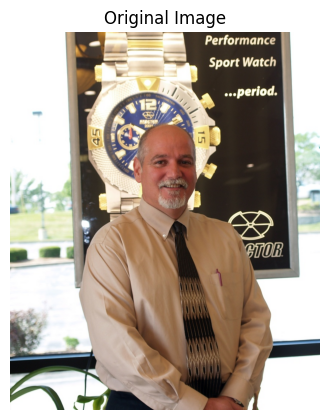

In [ ]:
import matplotlib.pyplot as plt

# Display the original image
plt.figure(figsize=(4, 6))
plt.imshow(image_rgb) # Use the RGB image for display
plt.title("Original Image")
plt.axis('off')
plt.show()


b. Draw bounding boxes and text on the image -

In [ ]:
import cv2
import pytesseract
import matplotlib.pyplot as plt

# Get bounding box and text data from pytesseract
data = pytesseract.image_to_data(image_rgb, output_type=pytesseract.Output.DICT)

n_boxes = len(data['level'])
overlay_image = image_rgb.copy() # Create a copy to draw on

filtered_boxes_count = 0

print("--- OCR Detections Details ---")
# Draw bounding boxes and text on the image
for i in range(n_boxes):
    text = data['text'][i].strip()
    conf = int(data['conf'][i])

    # Print details for all detections (including filtered out ones)
    if text != '': # Only print if there's actual text content
        print(f"Box {i}: Text='{text}', Confidence={conf}")

    # Filter out empty text or low confidence detections if desired
    # Drawing all boxes by setting confidence threshold to 0
    if conf > 0 and text != '': # Draw all boxes with non-empty text
        (x, y, w, h) = (data['left'][i], data['top'][i], data['width'][i], data['height'][i])
        cv2.rectangle(overlay_image, (x, y), (x + w, y + h), (255, 255, 255), 2) # white rectangle
        cv2.putText(overlay_image, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2) # Blue text
    else:
        if text != '': # Count only meaningful text detections that were filtered
            filtered_boxes_count += 1

print(f"\nNumber of detected text boxes (confidence > 0 and non-empty text): {n_boxes - filtered_boxes_count}")
print(f"Number of detected text boxes filtered out (confidence <= 0 or empty text): {filtered_boxes_count}")



--- OCR Detections Details ---
Box 4: Text='au', Confidence=17
Box 5: Text='a4', Confidence=15
Box 7: Text='RY', Confidence=45
Box 8: Text='em', Confidence=37
Box 9: Text='au', Confidence=14
Box 13: Text='...period.', Confidence=11

Number of detected text boxes (confidence > 0 and non-empty text): 18
Number of detected text boxes filtered out (confidence <= 0 or empty text): 0


c. Display the image with bounding boxes -

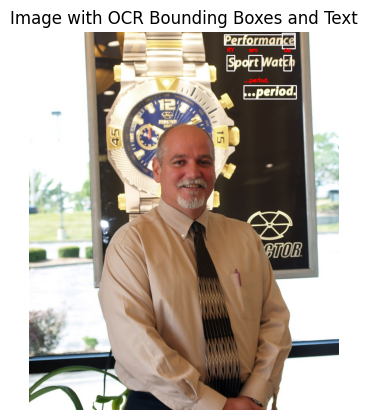

In [ ]:
# Display the image with bounding boxes
plt.figure(figsize=(4, 6))
plt.imshow(overlay_image)
plt.title("Image with OCR Bounding Boxes and Text")
plt.axis('off')
plt.show()

## **8. Assignment Summary**

We began by importing necessary libraries and downloading the TextOCR dataset. After loading the dataset, we extracted text from a sample image using Tesseract OCR and calculated its accuracy against the ground truth. The initial accuracy was quite low (normalized similarity ratio: **0.23**).

To improve the results, we then applied image pre-processing techniques (grayscaling, Otsu's thresholding, and median blur for noise removal) and re-evaluated the OCR accuracy. This led to a modest improvement in the normalized similarity ratio **(0.35)**.

Finally, we visualized the OCR results by displaying the original image and the image with detected text bounding boxes and their corresponding extracted text. By lowering the confidence threshold to 0, we were able to see all detected text boxes, confirming that many detections had very low confidence scores, which contributed to the overall low accuracy.

---